<a href="https://colab.research.google.com/github/zpsy-hub/Machine-Learning-and-Predictive-Analytics/blob/main/Machine_Learning_EDA_ver_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries and Reading Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# New Section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from tabulate import tabulate
from dateutil import parser
from sklearn.linear_model import LinearRegression

In [ ]:
df_customers = pd.read_csv("/content/drive/MyDrive/3rd year 2024-25/Term 2/Machine Learning and Predictive Analytics/raw data/customers_data.csv")
df_products = pd.read_csv("/content/drive/MyDrive/3rd year 2024-25/Term 2/Machine Learning and Predictive Analytics/raw data/products_data.csv")
df_transactions = pd.read_csv("/content/drive/MyDrive/3rd year 2024-25/Term 2/Machine Learning and Predictive Analytics/raw data/transactions_data.csv")

# **Data Overview**

In [ ]:
# Dictionary of DataFrames
dfs = {
    "customers": df_customers,
    "products": df_products,
    "transactions": df_transactions
}

### Data Types

In [ ]:
for name, df in dfs.items():
    print(f"Data types for {name}:")
    print(df.dtypes)
    print()

Data types for customers:
Company_ID        float64
Company_Name       object
Company_Profit    float64
Address            object
dtype: object

Data types for products:
Product_ID       float64
Product_Name      object
Product_Price     object
dtype: object

Data types for transactions:
Unnamed: 0          float64
Transaction_ID      float64
Company_ID          float64
Product_ID          float64
Quantity            float64
Transaction_Date     object
Product_Price       float64
Total_Cost          float64
dtype: object



### Summary Statistics

In [ ]:
for name, df in dfs.items():
    print(f"{name}:\n{df.describe()}\n")

customers:
       Company_ID  Company_Profit
count   90.000000       88.000000
mean    51.944444    76400.500000
std     28.684397    27296.169253
min      1.000000    30663.000000
25%     27.500000    52648.500000
50%     53.500000    75301.500000
75%     76.750000   101089.750000
max    100.000000   118114.000000

products:
       Product_ID
count   18.000000
mean    10.333333
std      6.077925
min      1.000000
25%      5.250000
50%     10.500000
75%     14.750000
max     20.000000

transactions:
        Unnamed: 0  Transaction_ID   Company_ID   Product_ID     Quantity  \
count  9000.000000     9000.000000  9000.000000  9000.000000  9000.000000   
mean   4994.049111     5005.177556    50.583556    10.446778    10.528778   
std    2885.331476     2894.971964    28.900870     5.768341     5.808062   
min       0.000000        1.000000     1.000000     1.000000     0.000000   
25%    2501.750000     2491.750000    25.000000     5.000000     6.000000   
50%    4997.500000     5005.00000

### Number of rows and columns in the DataFrame

In [ ]:
for name, df in dfs.items():
    print(f"{name}: {df.shape}")

customers: (100, 4)
products: (20, 3)
transactions: (10000, 8)


### First 5 rows of each data set


In [ ]:
for name, df in dfs.items():
    print(f"{name}:\n{tabulate(df.head(10), headers='keys', tablefmt='psql')}\n")

customers:
+----+--------------+----------------------+------------------+-------------------------------------------------------+
|    |   Company_ID | Company_Name         |   Company_Profit | Address                                               |
|----+--------------+----------------------+------------------+-------------------------------------------------------|
|  0 |            1 | Tech  Enterprises  1 |            80701 | EDSA, Barangay 606, Pasig, Philippines                |
|  1 |            2 | Global  Partners  2  |            80511 | Commonwealth Ave, Barangay 789, Taguig, Philippines   |
|  2 |            3 | Quantum Associates 3 |           110664 | Roxas Blvd, Barangay 505, Pasig, Philippines          |
|  3 |            4 | Prime Network 4      |              nan | Alabang-Zapote Rd, Barangay 202, Taguig, Philippines  |
|  4 |            5 | Elite  Ventures  5   |            69427 | Ayala Avenue, Barangay 101, Makati, Philippines       |
|  5 |          nan | Elite N

### Last 5 rows of each data set

In [ ]:
for name, df in dfs.items():
    print(f"{name}:\n{tabulate(df.tail(), headers='keys', tablefmt='psql')}\n")

customers:
+----+--------------+----------------------+------------------+------------------------------------------------------+
|    |   Company_ID | Company_Name         |   Company_Profit | Address                                              |
|----+--------------+----------------------+------------------+------------------------------------------------------|
| 95 |           96 | Dynamic  Network  96 |           101428 | Alabang-Zapote Rd, Brgy. 456, Cebu City, Philippines |
| 96 |           97 | Quantum Holdings 97  |            33449 | EDSA, Barangay 789, Manila, Philippines              |
| 97 |           98 | Pioneer Ventures 98  |            71095 | Roxas Blvd, Barangay 123, Taguig, Philippines        |
| 98 |          nan | Elite Corp 99        |           107929 | Alabang-Zapote Rd, Barangay 303, Makati, Philippines |
| 99 |          100 | Global Solutions 100 |              nan | Ayala avenue, barangay 456, taguig, philippines      |
+----+--------------+----------------

###Display Index, Columns, and Data

In [ ]:
for name, df in dfs.items():
  print(f"DataFrame Info for {name}:")
  df.info()
  print()

DataFrame Info for customers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company_ID      90 non-null     float64
 1   Company_Name    100 non-null    object 
 2   Company_Profit  88 non-null     float64
 3   Address         100 non-null    object 
dtypes: float64(2), object(2)
memory usage: 3.3+ KB

DataFrame Info for products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     18 non-null     float64
 1   Product_Name   20 non-null     object 
 2   Product_Price  20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes

DataFrame Info for transactions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 colum

## data overview summary


**`customers_data.csv`** - This dataset contains information about the companies, including their names, profits, and addresses.

|Column Name|Description|Data Type|Sample Data|
|:---|:---|:---|:---|
|Company_ID|Unique identifier for the company|float|1|
|Company_Name|Name of the company|obj|Tech Enterprises 1|
|Company_Profit|Profit of the company|float|80701|
|Address|Address of the company|obj|EDSA, Barangay 606, Pasig, Philippines|

Observations:


*   Company_ID: Missing a few IDs, need to be filled in order. Chaange float to int.
*   Company_Name: Need to be cleaned? Company_ID is included in the end. Looks like if you remove the numbers in the end, there are duplicate names.
*   Company_Profit: No currency indicated.
*   Address: Need to standardize format (Brngy vs Barangay). Fix Capitalization.




**`products_data.csv`** - This dataset contains information about the products, including their names and prices.

|Column Name|Description|Data Type|Sample Data|
|:---|:---|:---|:---|
|Product_ID|Unique identifier for the product|float|1|
|Product_Name|Name of the product|obj|FinPredictor Suite|
|Product_Price|Price of the product|obj|?140,000|

Observations:


*   Product_ID: Missing a few IDs, need to be filled in order.
*   Product_Name: No issues.
*   Product_Price: What currency? Need to standardize format.

**`transactions_data.csv`** - This dataset contains information about the transactions, including the company and product IDs, quantities, prices, and dates.

|Column Name|Description|Data Type|Sample Data|
|:---|:---|:---|:---|
|Unnamed: 0|Index of the row|float|0|
|Transaction_ID|Unique identifier for the transaction|float|1|
|Company_ID|Unique identifier for the company|float|88|
|Product_ID|Unique identifier for the product|float|6|
|Quantity|Quantity of the product|float|16|
|Transaction_Date|Date of the transaction|obj|2024/03/26|
|Product_Price|Price of the product|float|194379|
|Total_Cost|Total cost of the transaction|float|1.0752e+06|

Observations:
*   Unnamed: 0: Seems to be index of rows since  t starts with 0, can be dropped.
*   Transaction_ID: Missing data, seems to follow a sequential order (1,2,3,4, etc.). Change data type to int.
*   Company_ID: Missing Data. What to do? Drop data? Cannot be filled in since this is linked to the Company who purchased.
*   Product_ID: Matches the `Product_ID` column in the `products_data.csv` file.
*   Transaction_Date: Need to convert to datetime and standardize format.
*   Product_Price: Does not match Product_Price from `products_data.csv` (based on Product_ID)
*   Total_Cost: Does not match Quantity * Product Price\. Does not also match even if you get Quantity * Product Price (from `products_data.csv`)


Link with previous data:
*   The `Company_ID` column in the `transactions_data.csv` file matches the `Company_ID` column in the `customers_data.csv` file.

*   The `Product_ID` column in the `transactions_data.csv` file matches the `Product_ID` column in the `products_data.csv` file.
*   `Product_ID` is PK and FK, `Company_ID` is PK and FK, and `Transaction_ID` is PK.

# **Data Cleaning**

In [ ]:
customers = df_customers.copy()
products = df_products.copy()
transactions = df_transactions.copy()

## customers_data - data cleaning



In [ ]:
# Identify missing or non-sequential Company_IDs
existing_ids = customers['Company_ID'].dropna().astype(int).tolist()
all_ids = list(range(1, 101))
missing_values = sorted(set(all_ids) - set(existing_ids))

# Fill missing Company_IDs with forward-fill (ffill) method
customers['Company_ID'] = customers['Company_ID'].ffill()

# Count remaining missing values
remaining_missing_count = customers['Company_ID'].isna().sum()

# If there are still missing values, fill them directly from the missing values list
if remaining_missing_count > 0:
    customers.loc[customers['Company_ID'].isna(), 'Company_ID'] = missing_values[:remaining_missing_count]

# Final check for any missing Company_ID values
remaining_missing_count = customers['Company_ID'].isna().sum()

# Print the number of remaining missing values, or 0 if none
print(remaining_missing_count)

0


In [ ]:
# Convert `Address` to title case
customers["Address"] = customers["Address"].str.title()

# Replace 'Barangay' with 'Brgy.'
customers["Address"] = customers["Address"].str.replace(r"\bBarangay\b", "Brgy.", regex=True)

# Replace 'Avenue' with 'Ave.'
customers["Address"] = customers["Address"].str.replace(r"\bAvenue\b", "Ave.", regex=True)
customers["Address"] = customers["Address"].str.replace(r"\bAve\b(?!\.)", "Ave.", regex=True)

# Replace 'Blvd' with 'Blvd.'
customers["Address"] = customers["Address"].str.replace(r"\bBlvd\b(?!\.)", "Blvd.", regex=True)

# Replace 'Rd' with 'Rd.'
customers["Address"] = customers["Address"].str.replace(r"\bRd\b(?!\.)", "Rd.", regex=True)

# Replace 'Slex' with 'SLEX'
customers["Address"] = customers["Address"].str.replace(r"\bSlex\b", "SLEX", regex=True)

# Replace 'Edsa' with 'EDSA'
customers["Address"] = customers["Address"].str.replace(r"\bEdsa\b", "EDSA", regex=True)

# Remove '!'
customers["Address"] = customers["Address"].str.replace("!", "", regex=True)

customers


,Company_ID,Company_Name,Company_Profit,Address
0,1.0,Tech Enterprises 1,80701.0,"EDSA, Brgy. 606, Pasig, Philippines"
1,2.0,Global Partners 2,80511.0,"Commonwealth Ave., Brgy. 789, Taguig, Philippines"
2,3.0,Quantum Associates 3,110664.0,"Roxas Blvd., Brgy. 505, Pasig, Philippines"
3,4.0,Prime Network 4,NaN,"Alabang-Zapote Rd., Brgy. 202, Taguig, Philipp..."
4,5.0,Elite Ventures 5,69427.0,"Ayala Ave., Brgy. 101, Makati, Philippines"
...,...,...,...,...
95,96.0,Dynamic Network 96,101428.0,"Alabang-Zapote Rd., Brgy. 456, Cebu City, Phil..."
96,97.0,Quantum Holdings 97,33449.0,"EDSA, Brgy. 789, Manila, Philippines"
97,98.0,Pioneer Ventures 98,71095.0,"Roxas Blvd., Brgy. 123, Taguig, Philippines"
98,98.0,Elite Corp 99,107929.0,"Alabang-Zapote Rd., Brgy. 303, Makati, Philipp..."


In [ ]:
# Remove the digits from the `Company_Name` column
customers["Company_Name"] = customers["Company_Name"].str.replace("\d+", "", regex=True)

customers

,Company_ID,Company_Name,Company_Profit,Address
0,1.0,Tech Enterprises,80701.0,"EDSA, Brgy. 606, Pasig, Philippines"
1,2.0,Global Partners,80511.0,"Commonwealth Ave., Brgy. 789, Taguig, Philippines"
2,3.0,Quantum Associates,110664.0,"Roxas Blvd., Brgy. 505, Pasig, Philippines"
3,4.0,Prime Network,NaN,"Alabang-Zapote Rd., Brgy. 202, Taguig, Philipp..."
4,5.0,Elite Ventures,69427.0,"Ayala Ave., Brgy. 101, Makati, Philippines"
...,...,...,...,...
95,96.0,Dynamic Network,101428.0,"Alabang-Zapote Rd., Brgy. 456, Cebu City, Phil..."
96,97.0,Quantum Holdings,33449.0,"EDSA, Brgy. 789, Manila, Philippines"
97,98.0,Pioneer Ventures,71095.0,"Roxas Blvd., Brgy. 123, Taguig, Philippines"
98,98.0,Elite Corp,107929.0,"Alabang-Zapote Rd., Brgy. 303, Makati, Philipp..."


In [ ]:
# Check for duplicates in the 'Company_Name' column
duplicates = customers[customers.duplicated(subset=['Company_Name'], keep=False)]

# Print the number of duplicate company names
num_duplicates = len(duplicates)
print(f"Number of duplicate company names: {num_duplicates}")

# Print the duplicate company names
if num_duplicates > 0:
    print("\nDuplicate company names:")
    print(duplicates['Company_Name'].unique())
else:
    print("\nNo duplicate company names found.")

Number of duplicate company names: 47

Duplicate company names:
['Tech  Enterprises  ' 'Quantum Associates ' 'Prime Network '
 'Dynamic Solutions ' 'Pioneer Network ' 'Dynamic Ventures '
 'Quantum Network ' 'Sky Network ' 'Sky Ent.s ' 'Tech  Solutions  '
 'Tech Associates ' 'Elite Corp ' 'Quantum Holdings ' 'Sky Consulting '
 'Prime  Consulting  ' 'Pioneer Corp ' 'Prime Holdings '
 'Innovative Holdings ' 'Prime Industries ' 'Tech Ventures '
 'Global Solutions ' 'Quantum Solutions ']


In [ ]:
# Find rows containing "Quantum Network" in any column
rows_with_quantum_network = df_customers[customers.apply(lambda row: row.astype(str).str.contains('Quantum Network').any(), axis=1)]

# Print the rows with column names
print(rows_with_quantum_network.to_string(index=False))

 Company_ID       Company_Name  Company_Profit                                               Address
       12.0 Quantum Network 12         91671.0 Katipunan Ave, Barangay 123, Mandaluyong, Philippines
       43.0 Quantum Network 43        113336.0     Ortigas Ave, Barangay 404, Cebu City, Philippines


In [ ]:
# Fill company_profit with mean

# Calculate the mean of 'Company_Profit', excluding NaN values
mean_profit = customers['Company_Profit'].mean()

# Fill NaN values in 'Company_Profit' with the calculated mean
customers['Company_Profit'] = customers['Company_Profit'].fillna(mean_profit)

customers

,Company_ID,Company_Name,Company_Profit,Address
0,1.0,Tech Enterprises,80701.0,"EDSA, Brgy. 606, Pasig, Philippines"
1,2.0,Global Partners,80511.0,"Commonwealth Ave., Brgy. 789, Taguig, Philippines"
2,3.0,Quantum Associates,110664.0,"Roxas Blvd., Brgy. 505, Pasig, Philippines"
3,4.0,Prime Network,76400.5,"Alabang-Zapote Rd., Brgy. 202, Taguig, Philipp..."
4,5.0,Elite Ventures,69427.0,"Ayala Ave., Brgy. 101, Makati, Philippines"
...,...,...,...,...
95,96.0,Dynamic Network,101428.0,"Alabang-Zapote Rd., Brgy. 456, Cebu City, Phil..."
96,97.0,Quantum Holdings,33449.0,"EDSA, Brgy. 789, Manila, Philippines"
97,98.0,Pioneer Ventures,71095.0,"Roxas Blvd., Brgy. 123, Taguig, Philippines"
98,98.0,Elite Corp,107929.0,"Alabang-Zapote Rd., Brgy. 303, Makati, Philipp..."


In [ ]:
# Check data types of the 'customers' DataFrame
customers.dtypes

,0
Company_ID,float64
Company_Name,object
Company_Profit,float64
Address,object


## products_data - data cleaning


In [ ]:
products

,Product_ID,Product_Name,Product_Price
0,1.0,FinPredictor Suite,"?140,000"
1,2.0,MarketMinder Analytics,"?168,000"
2,3.0,TrendWise Forecaster,"?100,800"
3,4.0,CustomerScope Insights,"?123,200"
4,5.0,SalesSync Optimizer,"?84,000"
5,6.0,RevenueVue Dashboard,"?179,200"
6,7.0,DataBridge Integration Tool,"?151,200"
7,NaN,RiskRadar Monitor,"?151,200"
8,9.0,Product 9,"?112,000"
9,10.0,SegmentX Targeting,"?89,600"


In [ ]:
# Identify missing or non-sequential Product_IDs
existing_ids = products['Product_ID'].dropna().astype(int).tolist()
all_ids = list(range(1, 101))
missing_values = sorted(set(all_ids) - set(existing_ids))

# Fill missing Product_IDs with forward-fill (ffill) method
products['Product_ID'] = products['Product_ID'].ffill()

# Count remaining missing values
remaining_missing_count = products['Product_ID'].isna().sum()

# If there are still missing values, fill them directly from the missing values list
if remaining_missing_count > 0:
    products.loc[products['Product_ID'].isna(), 'Product_ID'] = missing_values[:remaining_missing_count]

# Final check for any missing Product_ID values
remaining_missing_count = products['Product_ID'].isna().sum()

# Print the number of remaining missing values, or 0 if none
print(remaining_missing_count)


0


In [ ]:
# Check data types of the 'customers' DataFrame
products.dtypes

,0
Product_ID,float64
Product_Name,object
Product_Price,object


In [ ]:
# Convert 'Product_Price' to numeric, handling errors
# Assuming 'Product_Price' might still contain non-numeric characters
products['Product_Price'] = pd.to_numeric(products['Product_Price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce').astype(float)

# Now, let's verify the changes and print the head:
print(products.dtypes)
print(products.head())

Product_ID       float64
Product_Name      object
Product_Price    float64
dtype: object
   Product_ID            Product_Name  Product_Price
0         1.0      FinPredictor Suite       140000.0
1         2.0  MarketMinder Analytics       168000.0
2         3.0    TrendWise Forecaster       100800.0
3         4.0  CustomerScope Insights       123200.0
4         5.0     SalesSync Optimizer        84000.0


## transactions_data - data cleaning


### Drop Unnamed: 0 column
This is an index row and is not needed.

In [ ]:
# Drop the 'Unnamed: 0' column
transactions = transactions.drop(columns=['Unnamed: 0'])

transactions.head(5)

,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,1.0,88.0,6.0,NaN,2024/03/26,194379.147964,1075200.0
1,2.0,29.0,19.0,16.0,"July 09, 2024",97930.993380,1428000.0
2,NaN,28.0,18.0,6.0,04/13/2024,126095.547778,940800.0
3,4.0,85.0,12.0,12.0,09-06-2023,NaN,1008000.0
4,5.0,47.0,3.0,8.0,07/06/2021,99575.609634,705600.0


### Fix Transaction_Date
Used dateutil.parser to fix the different date formats because `pandas.to_datetime()` is returning 7800 unparseable dates.

In [ ]:
# Custom function to parse dates using dateutil.parser
def parse_date(date_str):
    try:
        return parser.parse(date_str, fuzzy=True)
    except (ValueError, TypeError):
        return np.nan  # Return NaT for unparsable dates

# Apply the function to the 'Transaction_Date' column
transactions['Transaction_Date'] = transactions['Transaction_Date'].apply(parse_date)

# Count unparsed dates (NaT)
unparsed_count = transactions['Transaction_Date'].isna().sum()
print(f"Unparsed values count: {unparsed_count}")

# Show the result
print(transactions[['Transaction_Date']].head())

Unparsed values count: 0
  Transaction_Date
0       2024-03-26
1       2024-07-09
2       2024-04-13
3       2023-09-06
4       2021-07-06


### Checking trends in Numerical Data Sets for filling in missing data

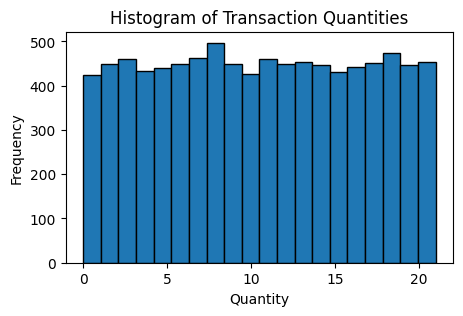

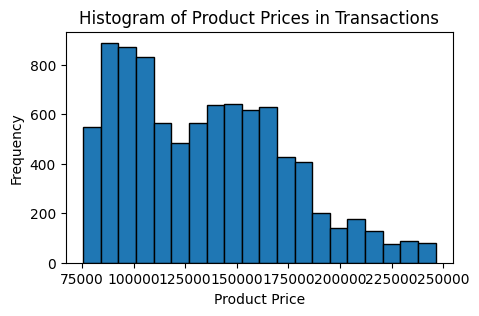

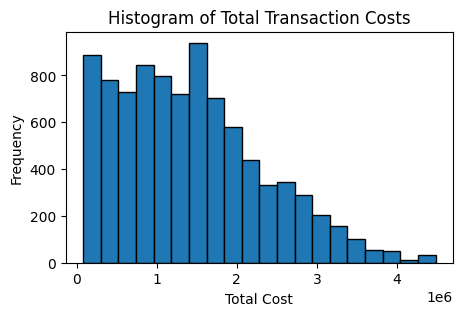

In [ ]:
# Histogram of all data in transactions
plt.figure(figsize=(5, 3))
plt.hist(transactions['Quantity'], bins=20, edgecolor='black')  # Adjust bins as needed
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Quantities')
plt.show()

plt.figure(figsize=(5, 3))
plt.hist(transactions['Product_Price'], bins=20, edgecolor='black')  # Adjust bins as needed
plt.xlabel('Product Price')
plt.ylabel('Frequency')
plt.title('Histogram of Product Prices in Transactions')
plt.show()

plt.figure(figsize=(5, 3))
plt.hist(transactions['Total_Cost'], bins=20, edgecolor='black')  # Adjust bins as needed
plt.xlabel('Total Cost')
plt.ylabel('Frequency')
plt.title('Histogram of Total Transaction Costs')
plt.show()

In [ ]:
# Drop rows where 'Company_ID' or 'Product_ID' is missing
transactions = transactions.dropna(subset=['Company_ID', 'Product_ID'])

# Fill missing 'Quantity' using both Company_ID and Product_ID
transactions['Quantity'] = transactions.groupby(['Company_ID', 'Product_ID'])['Quantity'].transform(
    lambda x: x.fillna(x.median())
)

transactions.isnull().sum()

,0
Transaction_ID,816
Company_ID,0
Product_ID,0
Quantity,18
Transaction_Date,0
Product_Price,802
Total_Cost,808
calculated_total_cost,1523
total_cost_match,0


### Checking Data Integrity if Quantity * Product_Price = Total_Cost

In [ ]:
# Calculate the expected total cost: Quantity * Product_Price
transactions['calculated_total_cost'] = transactions['Quantity'] * transactions['Product_Price']

# Compare the calculated total cost with the actual Total_Cost column
transactions['total_cost_match'] = transactions['calculated_total_cost'] == transactions['Total_Cost']

# Find rows where the total cost doesn't match
total_cost_mismatches = transactions[transactions['total_cost_match'] == False]

# Print the number of mismatches and the mismatched rows
print(f"Number of total cost mismatches: {total_cost_mismatches.shape[0]}")
print(total_cost_mismatches[['Transaction_ID', 'Product_ID', 'Quantity', 'Product_Price', 'Total_Cost', 'calculated_total_cost']])

Number of total cost mismatches: 10000
      Transaction_ID  Product_ID  Quantity  Product_Price  Total_Cost  \
0                1.0         6.0       NaN  194379.147964   1075200.0   
1                2.0        19.0      16.0   97930.993380   1428000.0   
2                NaN        18.0       6.0  126095.547778    940800.0   
3                4.0        12.0      12.0            NaN   1008000.0   
4                5.0         3.0       8.0   99575.609634    705600.0   
...              ...         ...       ...            ...         ...   
9995             NaN        10.0       NaN            NaN    627200.0   
9996          9997.0         2.0       9.0  159518.597391   1512000.0   
9997             NaN         1.0      15.0  128137.094759   1960000.0   
9998          9999.0         NaN      19.0   81786.119894   1680000.0   
9999             NaN        16.0      14.0  115708.404715   1489600.0   

      calculated_total_cost  
0                       NaN  
1              1.566896e

### Checking Data Integrity of Product Prices in Transactions Against Product Data by Product ID

In [ ]:
merged_transactions_products = pd.merge(
    transactions,
    products[['Product_ID', 'Product_Price']],
    left_on='Product_ID',
    right_on='Product_ID',
    how='left',
    suffixes=('_transaction', '_product')
)

# Compare the prices in the transaction with the prices in the products DataFrame
merged_transactions_products['price_match'] = merged_transactions_products['Product_Price_transaction'] == merged_transactions_products['Product_Price_product'] # Use actual column names

# Find rows where the prices don't match
price_mismatches = merged_transactions_products[merged_transactions_products['price_match'] == False]

# Print the number of mismatches and the mismatched rows
print(f"Number of price mismatches: {price_mismatches.shape[0]}")
print(price_mismatches[['Transaction_ID', 'Product_ID', 'Product_Price_transaction', 'Product_Price_product']]) # Use actual column names

Number of price mismatches: 10877
       Transaction_ID  Product_ID  Product_Price_transaction  \
0                 1.0         6.0              194379.147964   
1                 2.0        19.0               97930.993380   
2                 NaN        18.0              126095.547778   
3                 4.0        12.0                        NaN   
4                 5.0         3.0               99575.609634   
...               ...         ...                        ...   
10872             NaN        10.0                        NaN   
10873          9997.0         2.0              159518.597391   
10874             NaN         1.0              128137.094759   
10875          9999.0         NaN               81786.119894   
10876             NaN        16.0              115708.404715   

       Product_Price_product  
0                   179200.0  
1                    95200.0  
2                   134400.0  
3                    84000.0  
4                   100800.0  
...        